# Análisis y Limpieza de Datos de Ventas  
### Proyecto de Portafolio – Miguel Ángel Palomera  

Python | Pandas | Google Colab  



#1. Carga del dataset

In [ ]:
import pandas as pd

df= pd.read_csv("/content/Copia de Data e_commerce.csv")
df=pd.DataFrame(df)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,4102,US-2021-102288,19/6/2021,23/6/2021,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,United States,Houston,...,77095.0,Central,OFF-AP-10002906,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0.444,1,0.8,-1.1100
1,9293,CA-2021-124114,2/3/2021,2/3/2021,Same Day,RS-19765,Roland Schwarz,Corporate,United States,Waco,...,76706.0,Central,OFF-BI-10004022,Office Supplies,Binders,Acco Suede Grain Vinyl Round Ring Binder,0.556,1,0.8,-0.9452
2,8659,CA-2020-168361,21/6/2020,25/6/2020,Standard Class,KB-16600,Ken Brennan,Corporate,United States,Chicago,...,60623.0,Central,OFF-BI-10003727,Office Supplies,Binders,Avery Durable Slant Ring Binders With Label Ho...,0.836,1,0.8,-1.3376
3,4712,CA-2018-112403,31/3/2018,31/3/2018,Same Day,JO-15280,Jas O'Carroll,Consumer,United States,Philadelphia,...,19120.0,East,OFF-BI-10003529,Office Supplies,Binders,Avery Round Ring Poly Binders,0.852,1,0.7,-0.5964
4,2107,US-2018-152723,26/9/2018,26/9/2018,Same Day,HG-14965,Henry Goldwyn,Corporate,United States,Mesquite,...,75150.0,Central,OFF-BI-10003460,Office Supplies,Binders,Acco 3-Hole Punch,0.876,1,0.8,-1.4016


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          9994 non-null   int64  
 1   Order ID        9994 non-null   object 
 2   Order Date      9994 non-null   object 
 3   Ship Date       9994 non-null   object 
 4   Ship Mode       9994 non-null   object 
 5   Customer ID     9994 non-null   object 
 6   Customer Name   9994 non-null   object 
 7   Segment         9994 non-null   object 
 8   Country/Region  9994 non-null   object 
 9   City            9994 non-null   object 
 10  State           9994 non-null   object 
 11  Postal Code     9983 non-null   float64
 12  Region          9994 non-null   object 
 13  Product ID      9994 non-null   object 
 14  Category        9994 non-null   object 
 15  Sub-Category    9994 non-null   object 
 16  Product Name    9994 non-null   object 
 17  Sales           9994 non-null   f

#2. Análisis exploratorio inicial

In [ ]:
# Dimensiones
df.shape

(9994, 21)

In [ ]:
# Resumen Estadístico
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55245.233297,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
#Conteo de nulos
df.isnull().sum().sort_values(ascending=False)

,0
Postal Code,11
Order ID,0
Order Date,0
Ship Date,0
Row ID,0
Ship Mode,0
Customer ID,0
Segment,0
Customer Name,0
Country/Region,0


In [ ]:
# Búsqueda de valores únicos de una columna/lista en especifico mediante la función .unique
pd.Series(df['Ship Mode'].unique()).sort_values(ascending=False)

,0
0,Standard Class
3,Second Class
1,Same Day
2,First Class


In [ ]:
# Verificación de cuántas veces aparece cada tipo para validar importancia real en el negocio
df["Ship Mode"].value_counts()

,count
Ship Mode,
Standard Class,5968
Second Class,1945
First Class,1538
Same Day,543


In [ ]:
# Conversión a porcentajes
df["Ship Mode"].value_counts(normalize=True).mul(100).round(2).astype(str) + '%'

,proportion
Ship Mode,
Standard Class,59.72%
Second Class,19.46%
First Class,15.39%
Same Day,5.43%


El análisis de los modos de envío **evidencia que el 59.72% **de los pedidos se procesan bajo la **modalidad Standard Class**, lo que indica que la operación logística está claramente orientada a la optimización de costos por encima de la velocidad de entrega. Esto sugiere una estrategia conservadora enfocada en eficiencia operativa.

Por otro lado, los servicios acelerados (**Second Class con 19.46% y First Class con 15.39%**) representan en conjunto **más del 34% de los envíos**, lo que confirma la existencia de un segmento de clientes dispuesto a pagar por rapidez, abriendo oportunidades de optimización en estrategias comerciales y paquetes premium de servicio.

Finalmente, el bajo uso de la modalidad **Same Day (5.43%)** indica una **adopción limitada del servicio exprés**, lo cual puede estar asociado a costos elevados, restricciones de cobertura o bajo posicionamiento comercial.

Esto representa una oportunidad para analizar la viabilidad del servicio, ajustar su propuesta de valor o rediseñar la estrategia de promoción.

#3. Limpieza y transformación de datos

### Conversión de fechas

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [ ]:
df[["Order Date", "Ship Date"]].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


In [ ]:
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2021-06-19,2021-06-23
1,2021-03-02,2021-03-02
2,2020-06-21,2020-06-25
3,2018-03-31,2018-03-31
4,2018-09-26,2018-09-26


### Eliminación de duplicados

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

Se identificaron y eliminaron registros duplicados para garantizar la integridad de la información.

### Limpieza del Postal Code

In [ ]:
df["Postal Code"] = df["Postal Code"].astype("Int64").astype(str)
df["Postal Code"] = df["Postal Code"].replace("<NA>", "Unknown")

In [ ]:
df["Postal Code"].isna().sum()

np.int64(0)

Se identificaron y reemplazaron registros sin código postal o desconocidos para garantizar la integridad de la información

### Limpieza de Texto

In [ ]:
# Evitar errores silenciosos en catálogo
text_cols = ['Ship Mode', 'Segment', 'Country/Region', 'State',
             'City', 'Region', 'Category', 'Sub-Category', 'Product Name'] # Columnas que contienen datos categóricos o nombres como etiquetas

df[text_cols] = df[text_cols].apply(lambda x: x.str.strip()) # Con función lambda se eliminan espacios invisibles al inicio y al final de cada texto de las columnas etiquetadas

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,4102,US-2021-102288,2021-06-19,2021-06-23,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,United States,Houston,...,77095,Central,OFF-AP-10002906,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0.444,1,0.8,-1.1100
1,9293,CA-2021-124114,2021-03-02,2021-03-02,Same Day,RS-19765,Roland Schwarz,Corporate,United States,Waco,...,76706,Central,OFF-BI-10004022,Office Supplies,Binders,Acco Suede Grain Vinyl Round Ring Binder,0.556,1,0.8,-0.9452
2,8659,CA-2020-168361,2020-06-21,2020-06-25,Standard Class,KB-16600,Ken Brennan,Corporate,United States,Chicago,...,60623,Central,OFF-BI-10003727,Office Supplies,Binders,Avery Durable Slant Ring Binders With Label Ho...,0.836,1,0.8,-1.3376
3,4712,CA-2018-112403,2018-03-31,2018-03-31,Same Day,JO-15280,Jas O'Carroll,Consumer,United States,Philadelphia,...,19120,East,OFF-BI-10003529,Office Supplies,Binders,Avery Round Ring Poly Binders,0.852,1,0.7,-0.5964
4,2107,US-2018-152723,2018-09-26,2018-09-26,Same Day,HG-14965,Henry Goldwyn,Corporate,United States,Mesquite,...,75150,Central,OFF-BI-10003460,Office Supplies,Binders,Acco 3-Hole Punch,0.876,1,0.8,-1.4016


### Creación de columna nueva para tiempo de entrega

In [ ]:
# Se crea variable para saber los días que tarda un pedido en entregarse
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days # dt.days Convierte # entero de días

In [ ]:
 # SE muestran los reultados de la nueva columna creada
 df['Delivery Days'].describe().round(2)

,Delivery Days
count,9994.00
mean,3.96
std,1.75
min,0.00
25%,3.00
50%,4.00
75%,5.00
max,7.00


In [ ]:
# Promedio de entregas
df["Delivery Days"].mean().round(2)

np.float64(3.96)

In [ ]:
#Por tipo de envío
df.groupby("Ship Mode")["Delivery Days"].mean().round(2)

,Delivery Days
Ship Mode,
First Class,2.18
Same Day,0.04
Second Class,3.24
Standard Class,5.01


In [ ]:
# Analisis de desempeño de entregas de menor a mayor tiempo
df.groupby('Ship Mode')['Delivery Days'].mean().sort_values().round(2)

,Delivery Days
Ship Mode,
Same Day,0.04
First Class,2.18
Second Class,3.24
Standard Class,5.01


In [ ]:
# Y por región
df.groupby("Region")["Delivery Days"].mean().round(2)

,Delivery Days
Region,
Central,4.06
East,3.91
South,3.96
West,3.93


Generé la variable **Delivery Days** calculando la diferencia entre las fechas de pedido y envío, permitiendo medir así, los tiempos reales de despacho del pedido y analizando el desempeño logístico por modalidad, región y segmento. Obteniendo un promedio cercano a los 4 días

#4. Análisis de ventas

### Ventas y rentabilidad general

In [ ]:
total_sales = df["Sales"].sum() #Total vendido
total_profit = df["Profit"].sum() #Total de ganacias
total_sales, total_profit

(np.float64(2297200.8603), np.float64(286397.0217))

In [ ]:
profit_margin = (total_profit / total_sales) * 100
round(profit_margin, 2)

np.float64(12.47)

In [ ]:
print(f"Ventas totales: ${total_sales:,.2f}")
print(f"Utilidad total: ${total_profit:,.2f}")
print(f"Margen de utilidad: {profit_margin:.2f}%")

Ventas totales: $2,297,200.86
Utilidad total: $286,397.02
Margen de utilidad: 12.47%


In [ ]:
#Rentabilidad por línea de negocio
(df.groupby('Category')['Profit'].sum() / df.groupby('Category')['Sales'].sum() * 100).round(2)


,0
Category,
Furniture,2.49
Office Supplies,17.04
Technology,17.40


El análisis del margen por categoría revela que Technology y Office Supplies son las líneas más rentables, con márgenes superiores al 17%, mientras que Furniture presenta un margen crítico de 2.49%, indicando problemas de eficiencia o estructura de costos. Con estos resultados se sugieren oportunidades claras de optimización en precios, descuentos y logística para la categoría de mueble. Por oto lado se concluye que las otras dos categorías pueden considerarse pilares financieros del negocio.

### Ventas por categoría

In [ ]:
ventas_categoria = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
ventas_categoria

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


### Rentabilidad por subcategorías

In [ ]:
# Cálculo del margen de ganancia por subcategoría:
# 1) Se agregan las ventas y utilidades totales por subcategoría
# 2) Se calcula el margen porcentual (Profit / Sales)
# 3) Se ordenan los resultados de mayor a menor para identificar las subcategorías más rentables
sales_sc = df.groupby('Sub-Category')['Sales'].sum()
profit_sc = df.groupby('Sub-Category')['Profit'].sum()

margin_sc = (profit_sc / sales_sc * 100).round(2).sort_values(ascending=False)
margin_sc.head()


,0
Sub-Category,
Labels,44.42
Paper,43.39
Envelopes,42.27
Copiers,37.20
Fasteners,31.40


El análisis de rentabilidad por subcategoría muestra que productos como Labels, Paper y Envelopes presentan márgenes superiores al 40%, convirtiéndose en los principales generadores de utilidad del negocio. Estas subcategorías, caracterizadas por alta rotación y bajos costos operativos, representan oportunidades estratégicas para potenciar volumen sin comprometer la rentabilidad. En contraste, subcategorías con menor margen requieren una evaluación conjunta con su volumen de ventas para determinar su impacto real en el resultado financiero.

In [ ]:
# Por ganacias
profit_subcat = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
profit_subcat

,Profit
Sub-Category,
Copiers,55617.8249
Phones,44515.7306
Accessories,41936.6357
Paper,34053.5693
Binders,30221.7633
Chairs,26590.1663
Storage,21278.8264
Appliances,18138.0054
Furnishings,13059.1436


In [ ]:
# Por Ventas
ventas_subcat = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).round(2)
ventas_subcat.head()

,Sales
Sub-Category,
Phones,330007.05
Chairs,328449.10
Storage,223843.61
Tables,206965.53
Binders,203412.73


In [ ]:
# ¿Qué subcategorías venden más dinero?
# venden poco pero dejan mucho margen o venden mucho pero dejan poco
sales_sc.sort_values(ascending=False).round(2)

,Sales
Sub-Category,
Phones,330007.05
Chairs,328449.10
Storage,223843.61
Tables,206965.53
Binders,203412.73
Machines,189238.63
Accessories,167380.32
Copiers,149528.03
Bookcases,114880.00


El análisis cruzado entre volumen de ventas y margen por subcategoría evidencia dos grupos estratégicos: subcategorías de alto volumen como Phones y Chairs, que sostienen los ingresos, y subcategorías de bajo volumen pero alto margen como Labels, Paper y Envelopes, que son clave para la rentabilidad del negocio. Esta diferenciación permite orientar decisiones comerciales equilibrando crecimiento en ingresos y maximización de utilidad.

### Ventas por región

In [ ]:
ventas_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
ventas_region

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


Se analizaron indicadores clave como ventas totales, utilidad, margen promedio y desempeño por categoria y región. Asimismo, se evaluó el tiempopromedio de entrega por modalidad de envío, permitiendo identificar diferencias operativas relevantes.

**Así mimso se puede observar que aunque Phones lidera en ventas, Copiers es la subcategoría más rentable, lo que sugiere un mayor margen por unidad. Esto abre oportunidades para priorizar su promoción o replicar su estrategia de pricing en otras líneas.**

#5. Visualización de resultados

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

### Gráfica de Modods de Envío (% Ship Mode)

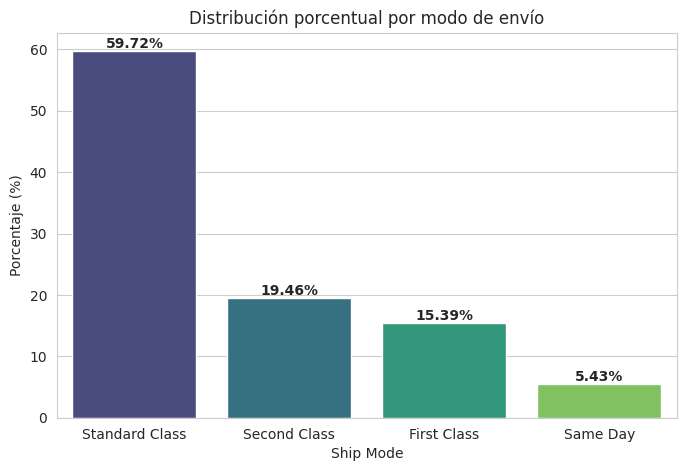

In [ ]:
shipmode_pct = df['Ship Mode'].value_counts(normalize=True).mul(100).round(2)

plt.figure(figsize=(8,5))
sns.barplot(
    x=shipmode_pct.index,
    y=shipmode_pct.values,
    hue=shipmode_pct.index,        # Nueva función hue requerida
    legend=False,                  # ocultar leyenda
    palette="viridis"
)

plt.title("Distribución porcentual por modo de envío")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Ship Mode")

for i, v in enumerate(shipmode_pct.values):
    plt.text(i, v + 0.5, f"{v}%", ha='center', fontweight='bold')

plt.show()

### Gráfica de Ventas por Categoría

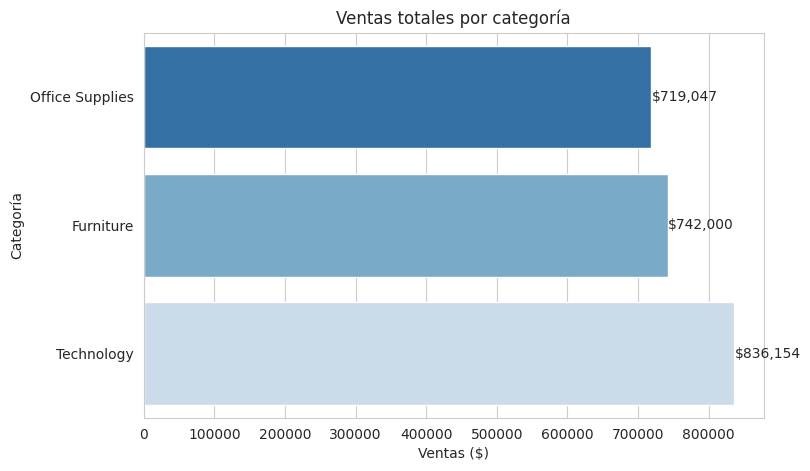

In [ ]:
ventas_categoria = df.groupby('Category')['Sales'].sum().sort_values()

plt.figure(figsize=(8,5))
sns.barplot(
    x=ventas_categoria.values,
    y=ventas_categoria.index,
    hue=ventas_categoria.index,     # nuevo
    legend=False,
    palette="Blues_r"
)

plt.title("Ventas totales por categoría")
plt.xlabel("Ventas ($)")
plt.ylabel("Categoría")

for i, v in enumerate(ventas_categoria.values):
    plt.text(v + 1000, i, f"${v:,.0f}", va='center')

plt.show()

### Gráfica de Rentabilidad por Categoría

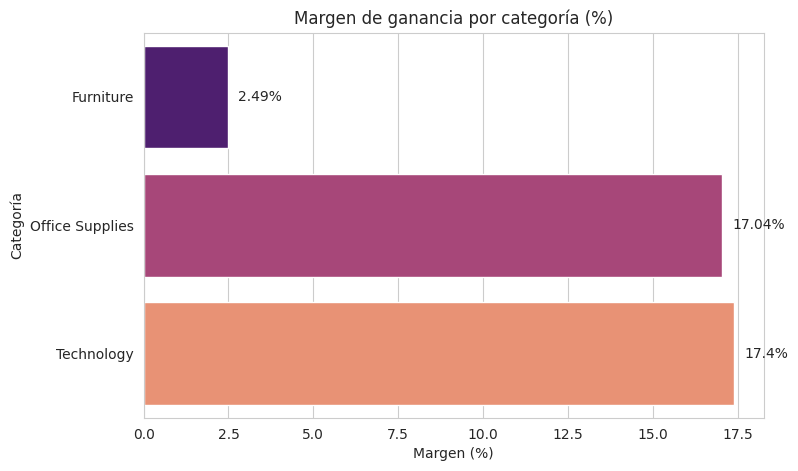

In [ ]:
profit_margin = (
    df.groupby('Category')['Profit'].sum()
    / df.groupby('Category')['Sales'].sum()
) * 100

profit_margin = profit_margin.round(2)

plt.figure(figsize=(8,5))
sns.barplot(
    x=profit_margin.values,
    y=profit_margin.index,
    hue=profit_margin.index,
    legend=False,
    palette="magma"
)

plt.title("Margen de ganancia por categoría (%)")
plt.xlabel("Margen (%)")
plt.ylabel("Categoría")

for i, v in enumerate(profit_margin.values):
    plt.text(v + 0.3, i, f"{v}%", va='center')

plt.show()

### Gráfica del Tiempo de Enregas por Modo de Envío

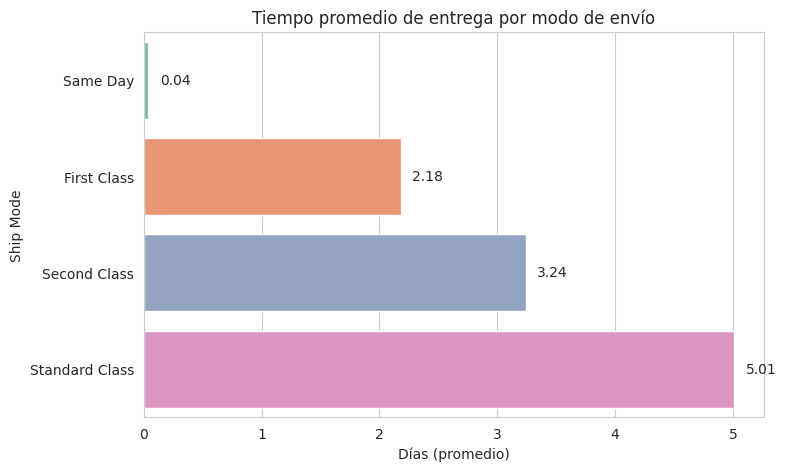

In [ ]:
delivery_avg = df.groupby('Ship Mode')['Delivery Days'].mean().sort_values().round(2)

plt.figure(figsize=(8,5))
sns.barplot(
    x=delivery_avg.values,
    y=delivery_avg.index,
    hue=delivery_avg.index,
    legend=False,
    palette="Set2"
)

plt.title("Tiempo promedio de entrega por modo de envío")
plt.xlabel("Días (promedio)")
plt.ylabel("Ship Mode")

for i, v in enumerate(delivery_avg.values):
    plt.text(v + 0.1, i, v, va='center')

plt.show()

### Gráfica de las Ventas y la Rentabilidad General

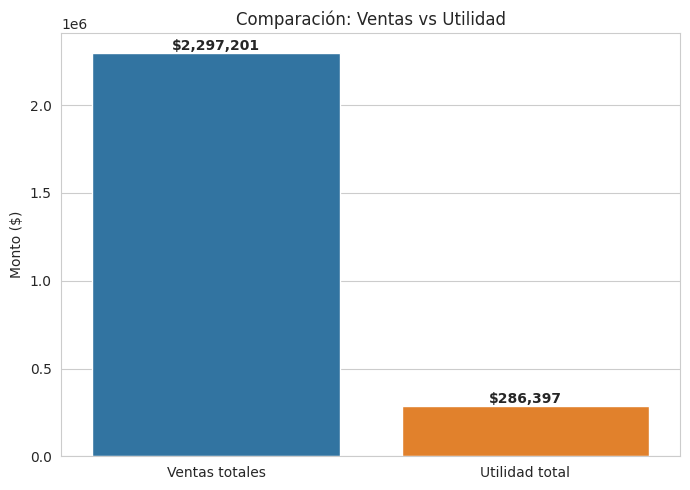

In [ ]:
# Ventas vs utilidad
kpis = pd.DataFrame({
    'Metrica': ['Ventas totales', 'Utilidad total'],
    'Valor': [total_sales, total_profit]
})

plt.figure(figsize=(7,5))
sns.barplot(
    data=kpis,
    x='Metrica',
    y='Valor',
    hue='Metrica',
    legend=False
)

plt.title('Comparación: Ventas vs Utilidad')
plt.ylabel('Monto ($)')
plt.xlabel('')

for i, v in enumerate(kpis['Valor']):
    plt.text(i, v, f"${v:,.0f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Gráficas de Ventas y rentabilidad por Sub-categoría

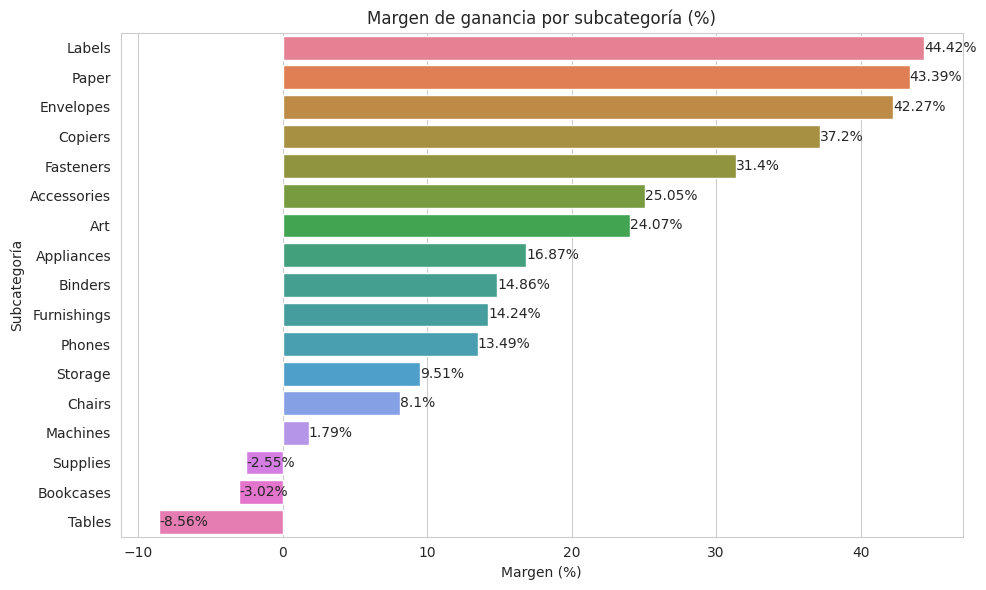

In [ ]:
#Gráfico de márgenes de ganancias por subcategoria (Rentabilidad)
plt.figure(figsize=(10,6))
sns.barplot(
    x=margin_sc.values,
    y=margin_sc.index,
    hue=margin_sc.index,
    legend=False
)

plt.title('Margen de ganancia por subcategoría (%)')
plt.xlabel('Margen (%)')
plt.ylabel('Subcategoría')

for i, v in enumerate(margin_sc.values):
    plt.text(v, i, f"{v}%", va='center', ha='left')

plt.tight_layout()
plt.show()

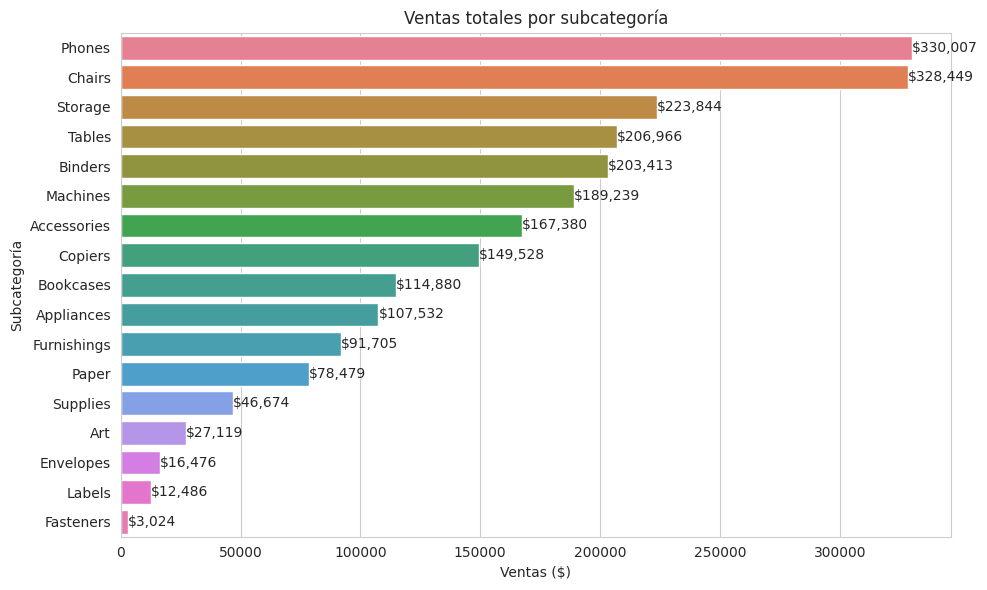

In [ ]:
#Grafico de ventas por subcategoria
plt.figure(figsize=(10,6))
sns.barplot(
    x=ventas_subcat.values,
    y=ventas_subcat.index,
    hue=ventas_subcat.index,
    legend=False
)

plt.title('Ventas totales por subcategoría')
plt.xlabel('Ventas ($)')
plt.ylabel('Subcategoría')

for i, v in enumerate(ventas_subcat.values):
    plt.text(v, i, f"${v:,.0f}", va='center', ha='left')

plt.tight_layout()
plt.show()

Se generaron visualizaciones comparando ventas totales vs utilidad, así como análisis detallado por subcategoría, identificando tanto las líneas con mayor volumen de ventas como aquellas con mejor margen de rentabilidad. Esto permitió detectar subcategorías estratégicas y otras que requieren revisión de precios, descuentos o costos operativos.

#6. Exportación del dataset limpio

Una vez completado el proceso de limpieza y transformación,
se exporta una versión depurada del dataset para garantizar
su reutilización en análisis posteriores y herramientas de
visualización como Power BI o Tableau.

In [58]:
#Exportación del dataset limpio.
#Este archivo contiene los datos depurados y transformados, listos para su reutilización en análisis posteriores,
#visualización en herramientas BI o integración en pipelines de datos.

cols_finales = [
    'Order Date', 'Ship Date', 'Delivery Days',
    'Segment', 'Category', 'Sub-Category',
    'Sales', 'Profit', 'Ship Mode', 'Region'
]

df[cols_finales].to_csv(
    'ecommerce_clean_bi.csv',
    index=False,
    encoding='utf-8'
)

In [59]:
#Verificación de que el archivo efectivamente existe en el entorno
!ls

'Copia de Data e_commerce.csv'	 ecommerce_clean_bi.csv   sample_data


In [60]:
#Descarga a local del nuevo archivo

from google.colab import files

files.download('ecommerce_clean_bi.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
# Para guardarlo en Drive

from google.colab import drive
drive.mount('/content/drive')

df.to_csv('/content/drive/MyDrive/ecommerce_clean_bi.csv', index=False)

Mounted at /content/drive


#7. Conclusiones

## Comportamiento de ventas y rentabilidad

Las subcategorías con mayor volumen de ventas fueron:

Phones – $330,007

Chairs – $328,449

Storage – $223,844

Tables – $206,966

Binders – $203,413

Esto indica que los productos tecnológicos y de mobiliario concentran la mayor parte del ingreso total.

Sin embargo, alto volumen no siempre implica mayor rentabilidad.
Al analizar las ganancias absolutas, las subcategorías más rentables fueron:

Copiers – $55,617

Phones – $44,516

Accessories – $41,937

Destaca que Copiers, sin ser la subcategoría con más ventas, genera la mayor ganancia total, lo que sugiere precios más altos o mejores márgenes.

## Análisis de márgenes de ganacia

El análisis de margen (% de ganancia sobre ventas) mostró que las subcategorías más eficientes fueron:

Labels – 44.42%

Paper – 43.39%

Envelopes – 42.27%

Copiers – 37.20%

Fasteners – 31.40%

Esto revela que los productos de bajo costo unitario, aunque no lideran en ventas totales, ofrecen márgenes significativamente altos, siendo estratégicos para la rentabilidad del negocio

## Análisis de logística y tiempos de entrega

La distribución de pedidos por tipo de envío fue:

Standard Class: 59.72%

Second Class: 19.46%

First Class: 15.39%

Same Day: 5.43%

***Lo anterior indica que la mayoría de los clientes prioriza costos de envío más bajos sobre la velocidad.***

En cuanto a tiempos promedio de entrega:

Same Day: 0.04 días

First Class: 2.18 días

Second Class: 3.24 días

Standard Class: 5.01 días

Existe una correlación clara entre tipo de envío y tiempo de entrega, validando la consistencia operativa del proceso logístico.

## Conclusión general

El análisis permite concluir que el negocio depende en gran medida de categorías de alto volumen, como Phones y Chairs, las cuales cumplen un papel clave en la atracción y generación de flujo de clientes. Sin embargo, la rentabilidad real del negocio se ve reforzada principalmente por subcategorías de alto margen, como Labels, Paper y Copiers, que aportan una mayor utilidad por cada unidad vendida.

Desde el punto de vista logístico, la estrategia actual se encuentra alineada con el comportamiento del cliente, ya que la mayoría de los pedidos se concentran en envíos estándar, priorizando costos más bajos sobre entregas inmediatas, lo que confirma la coherencia entre la operación logística y la demanda del mercado.

A partir de estos hallazgos, se identifican áreas de oportunidad claras para fortalecer el desempeño comercial del negocio:

Potenciar productos de alto margen mediante estrategias de upselling, identificando combinaciones de compra frecuentes y priorizando recomendaciones hacia subcategorías más rentables, en lugar de enfocar los esfuerzos únicamente en productos populares o de alto volumen.

Revisar el desempeño de subcategorías con altas ventas pero menor eficiencia de ganancia, con el objetivo de evitar costos logísticos elevados, descuentos excesivos y márgenes comprimidos que puedan afectar la rentabilidad global.

Optimizar la toma de decisiones comerciales combinando volumen y margen, en lugar de basarse exclusivamente en los productos que más se venden, permitiendo una visión más integral y financiera del portafolio de productos.

En conjunto, el análisis demuestra que una estrategia comercial efectiva no debe sustentarse únicamente en el volumen de ventas, sino en la combinación de volumen, margen y comportamiento del cliente. Identificar productos de alto margen para estrategias de upselling, optimizar subcategorías de alto volumen con baja eficiencia y priorizar decisiones basadas en rentabilidad permite maximizar el beneficio sin incrementar los costos operativos, fortaleciendo la sostenibilidad del negocio a largo plazo.

---  
**Este proyecto forma parte de mi portafolio personal orientado a análisis de datos e inteligencia de negocios.**
